In [29]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

In [16]:
data_path = "time series data.csv"
df = pd.read_csv(data_path, parse_dates=["t"], index_col="t")

df.head()

<ipython-input-16-7f542743e558>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(data_path, parse_dates=["t"], index_col="t")


,ProductP1,ProductP2,ProductP3,ProductP4,ProductP5,price,temperature
t,,,,,,,
1,197,66,266,113,2,1,18
2,153,44,264,74,1,2,21
3,128,55,317,116,0,1,19
4,133,57,390,70,0,2,17
5,120,47,440,141,1,1,18


In [17]:
# Step 2: Transform - Check for missing values
missing_summary = df.isnull().sum()
print("Missing Values Summary:\n", missing_summary)

Missing Values Summary:
 ProductP1      0
ProductP2      0
ProductP3      0
ProductP4      0
ProductP5      0
price          0
temperature    0
dtype: int64


In [18]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)

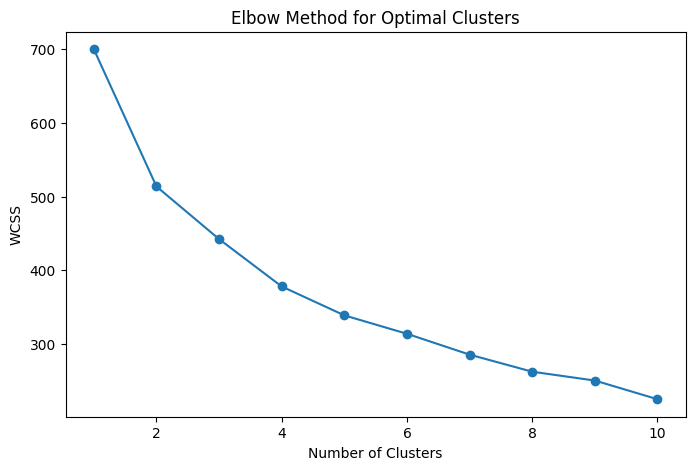

In [19]:
# -------------------- Clustering Analysis -------------------- #
# Determine the optimal number of clusters using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal Clusters')
plt.show()


In [22]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df_scaled)


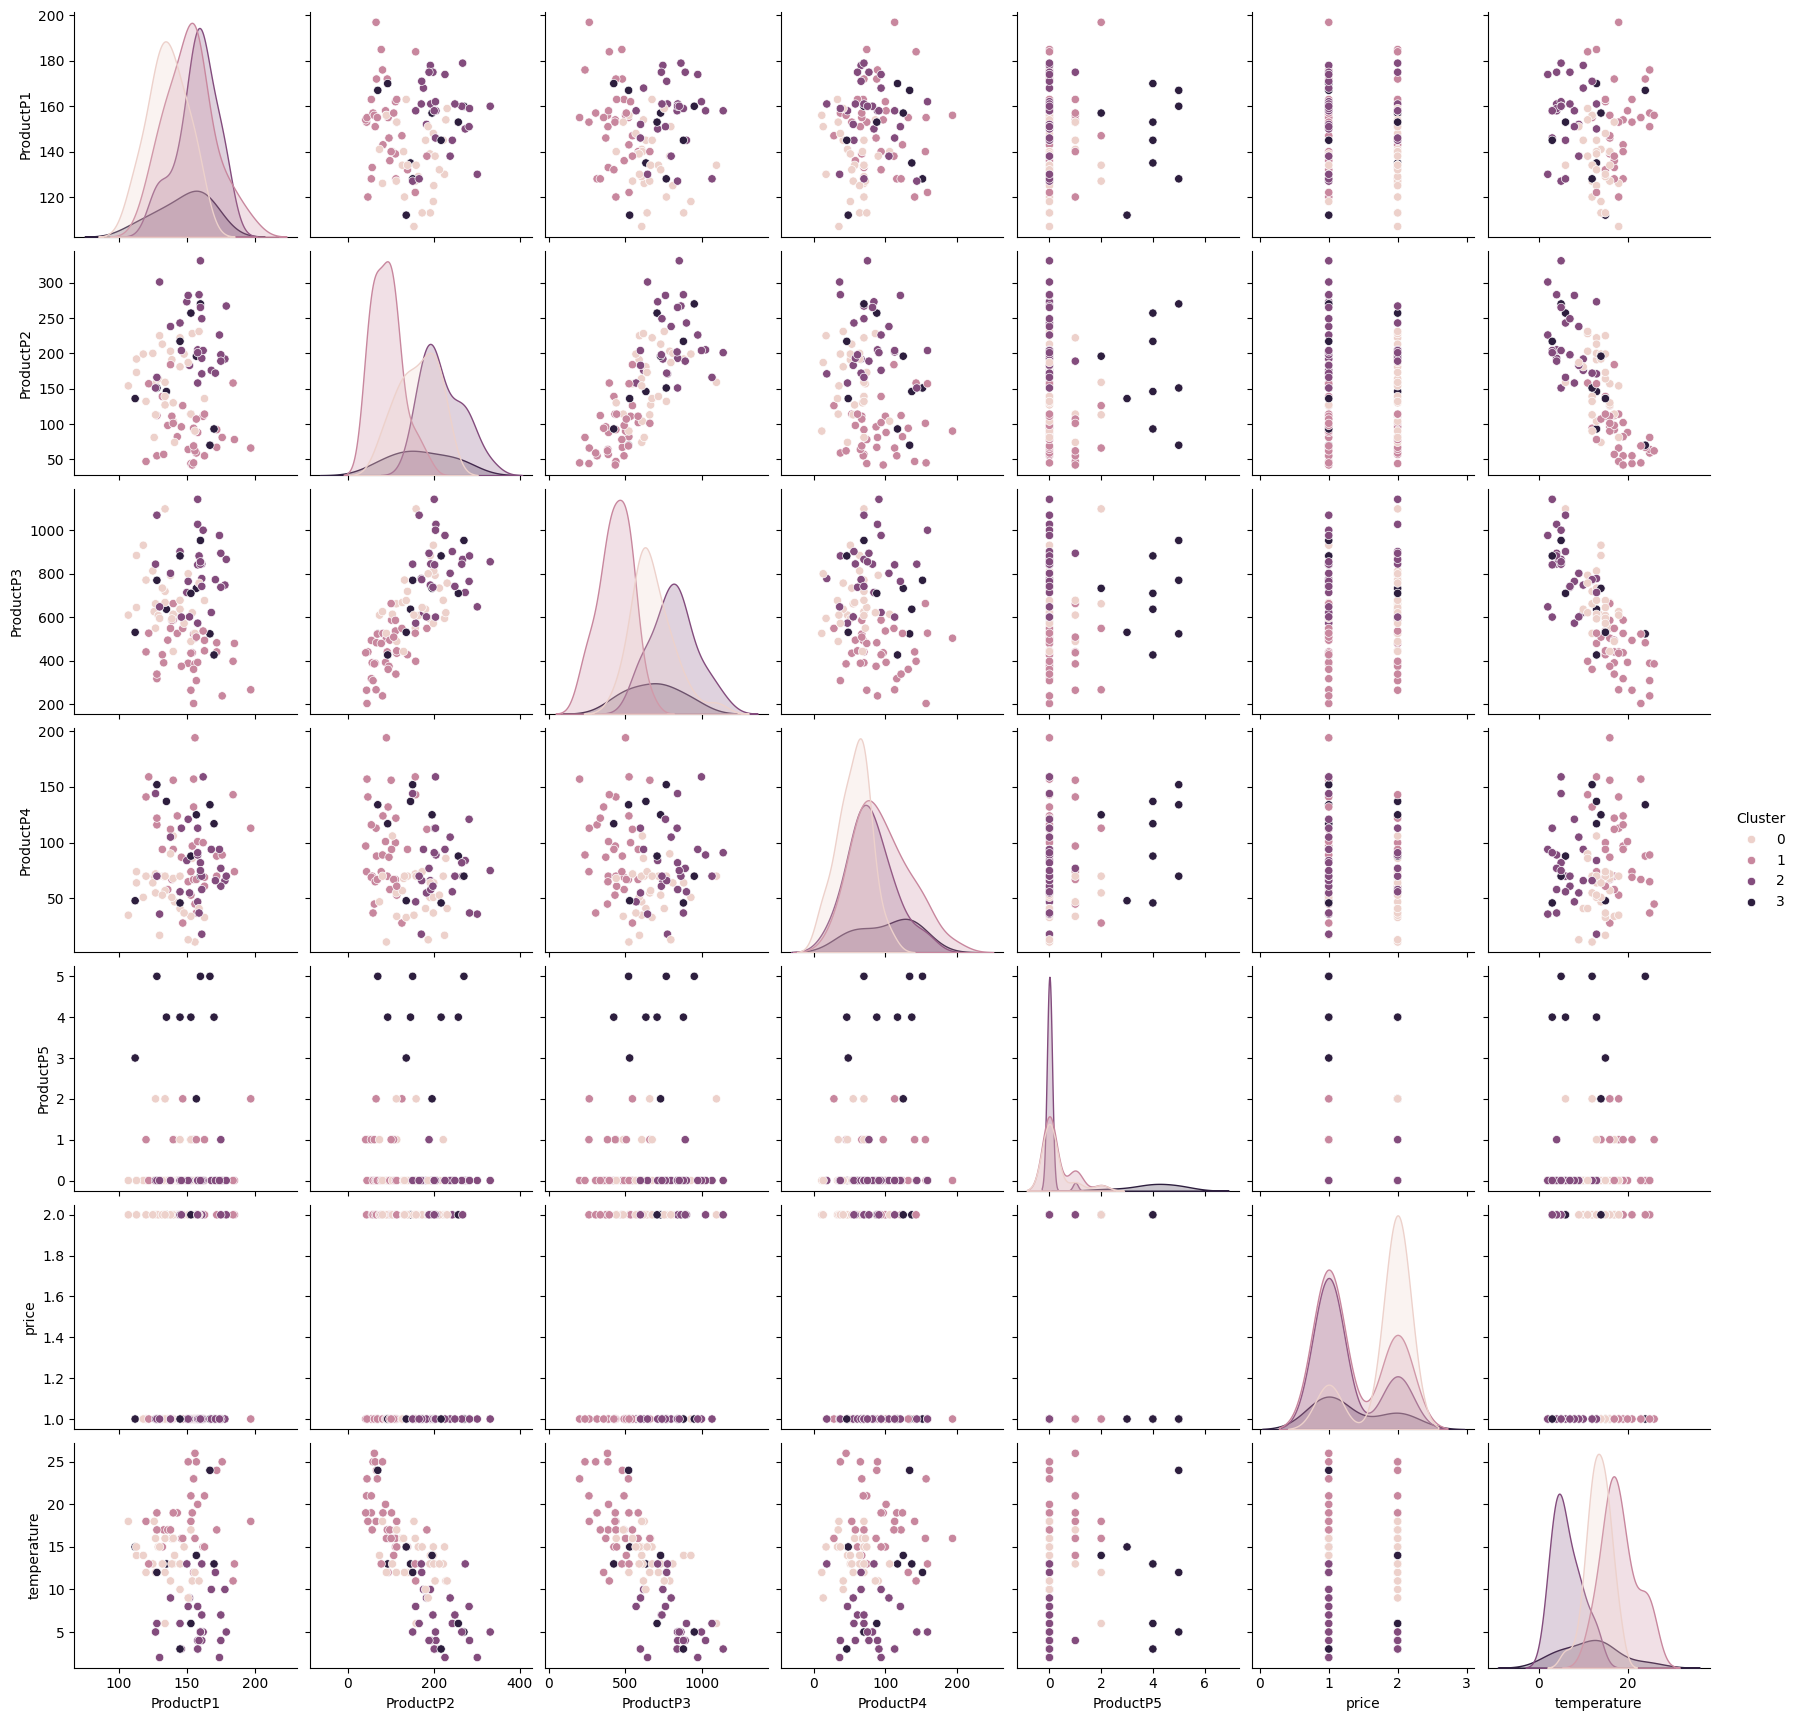

In [23]:
# Visualizing clusters
sns.pairplot(df, hue='Cluster', diag_kind='kde')
plt.show()


In [31]:
def adf_test(series, name):
    result = adfuller(series)
    print(f"{name}: ADF Statistic = {result[0]:.4f}, p-value = {result[1]:.4f}")
    if result[1] <= 0.05:
        print("Stationary (Reject H0)")
    else:
        print("Non-Stationary (Fail to Reject H0)")
    print("-" * 40)


In [32]:
# Perform ADF test for each product
for col in ['ProductP1', 'ProductP2', 'ProductP3', 'ProductP4', 'ProductP5']:
    adf_test(df[col], col)

ProductP1: ADF Statistic = -5.6756, p-value = 0.0000
Stationary (Reject H0)
----------------------------------------
ProductP2: ADF Statistic = -0.8616, p-value = 0.8004
Non-Stationary (Fail to Reject H0)
----------------------------------------
ProductP3: ADF Statistic = -0.2349, p-value = 0.9342
Non-Stationary (Fail to Reject H0)
----------------------------------------
ProductP4: ADF Statistic = -11.4555, p-value = 0.0000
Stationary (Reject H0)
----------------------------------------
ProductP5: ADF Statistic = -11.1525, p-value = 0.0000
Stationary (Reject H0)
----------------------------------------


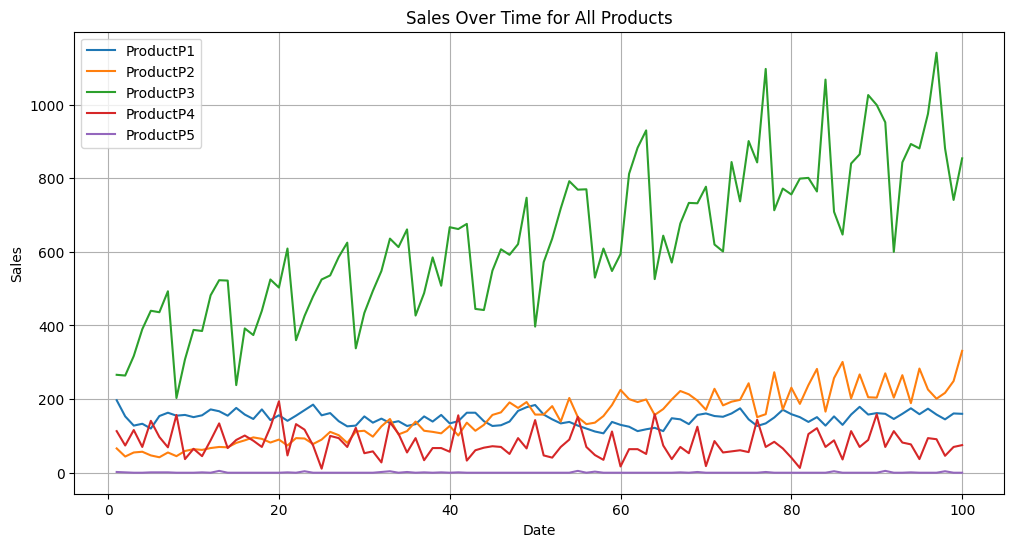

In [33]:
# Plot Time Series Data for all products
plt.figure(figsize=(12, 6))
for col in ['ProductP1', 'ProductP2', 'ProductP3', 'ProductP4', 'ProductP5']:
    plt.plot(df.index, df[col], label=col)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Sales Over Time for All Products')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# -------------------- Forecasting Model -------------------- #
# Forecasting ProductP4 (as it has explanatory variables)
endog = df['ProductP4']  # Dependent Variable
exog = df[['price', 'temperature']]  # Explanatory Variables

# Train-test split
train_size = int(len(df) * 0.8)
train, test = endog[:train_size], endog[train_size:]
exog_train, exog_test = exog[:train_size], exog[train_size:]


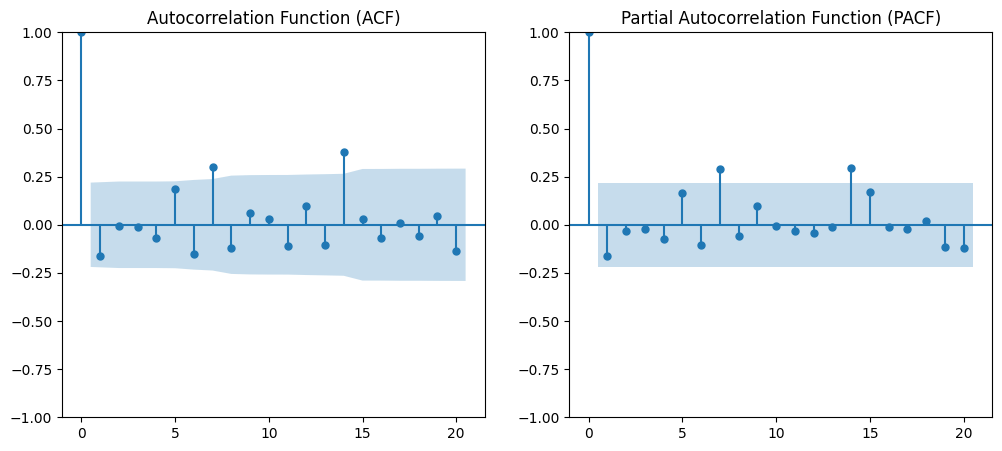

In [30]:
# ACF & PACF plots for stationarity analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(train, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF)")
plot_pacf(train, ax=axes[1])
axes[1].set_title("Partial Autocorrelation Function (PACF)")
plt.show()


In [25]:
# Forecast
forecast = results.predict(start=len(train), end=len(df)-1, exog=exog_test)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


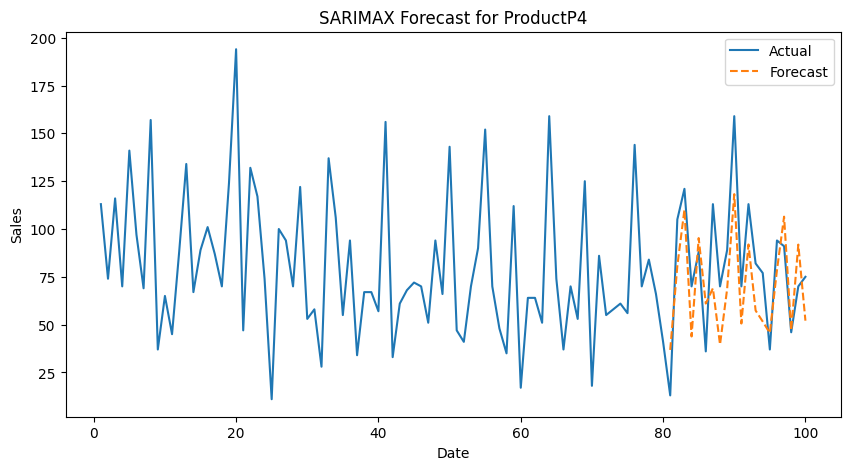

In [26]:
# Plot Forecast
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['ProductP4'], label='Actual')
plt.plot(test.index, forecast, label='Forecast', linestyle='dashed')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('SARIMAX Forecast for ProductP4')
plt.legend()
plt.show()

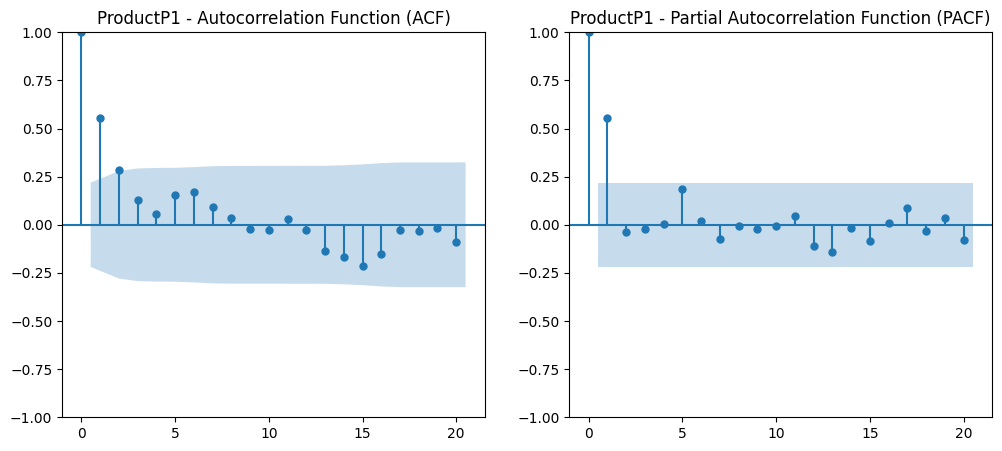

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index

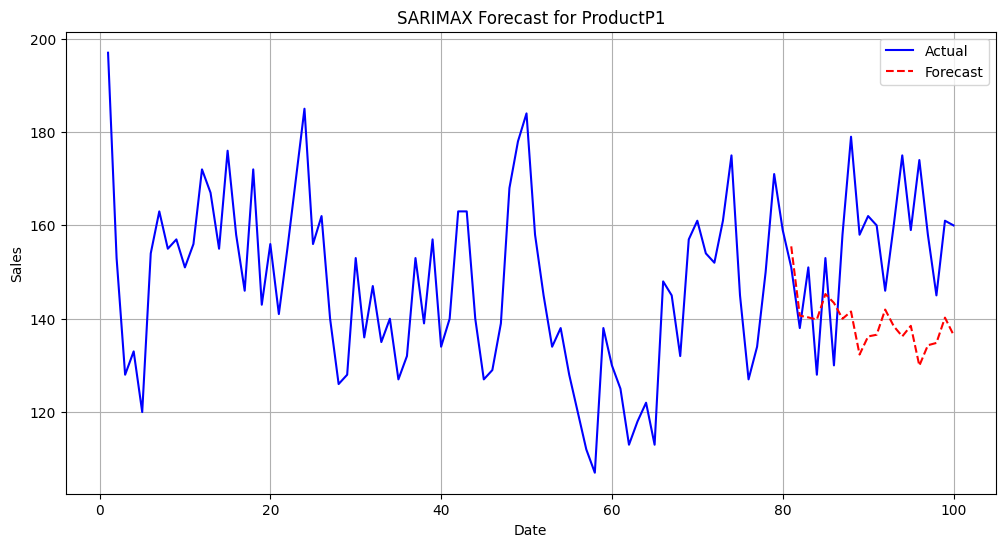

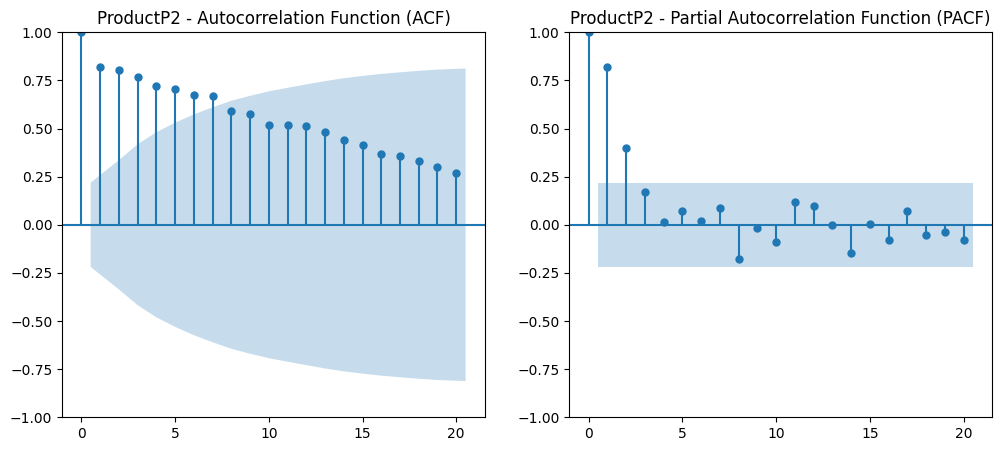

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_

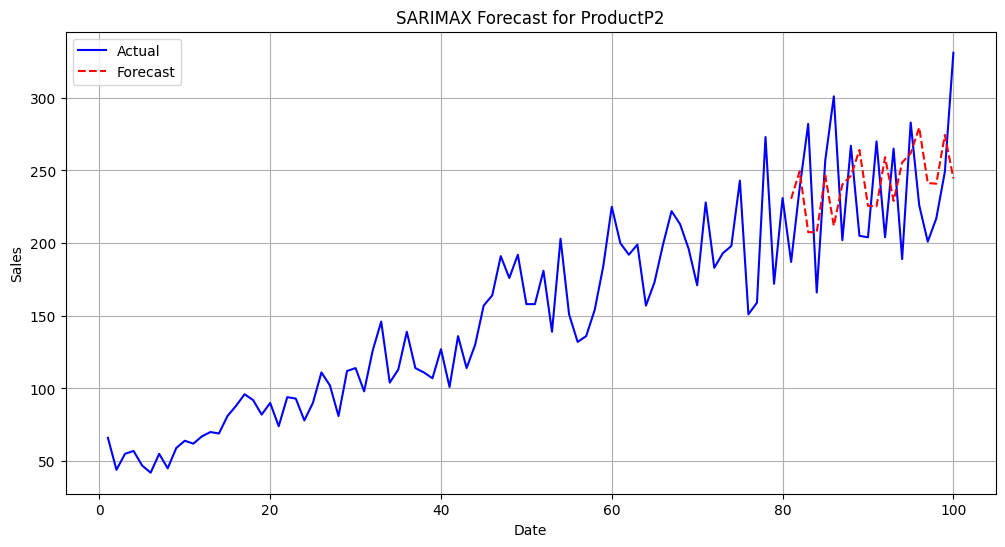

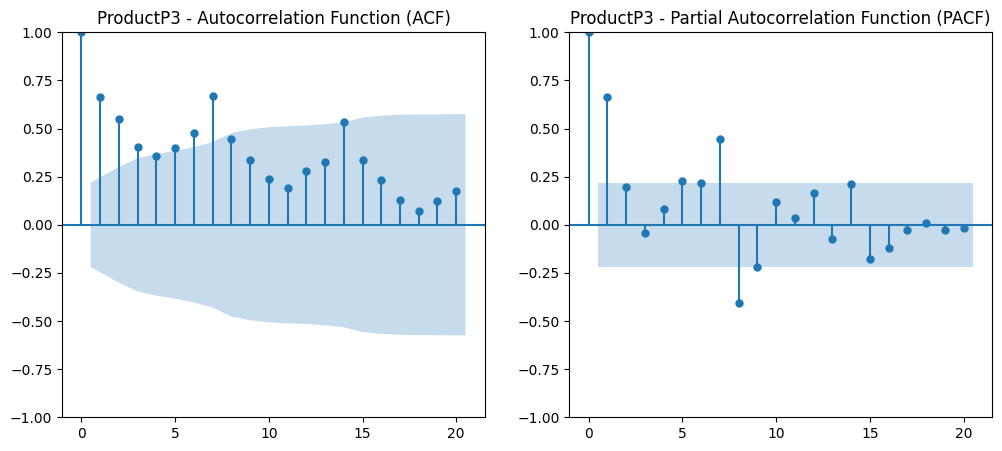

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index

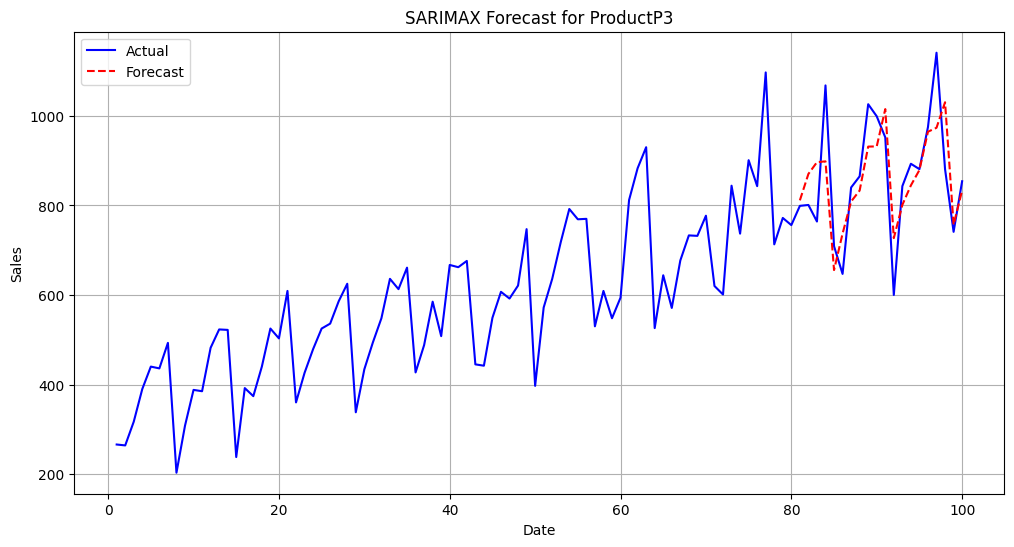

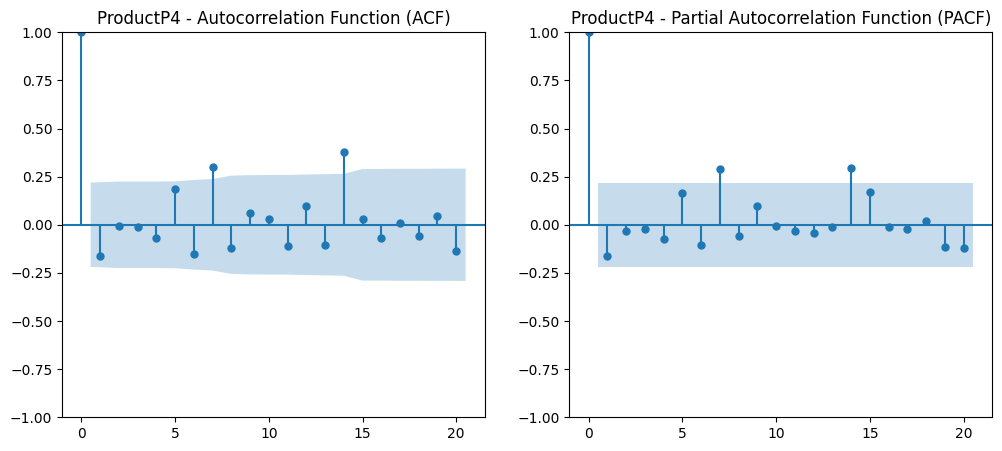

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_

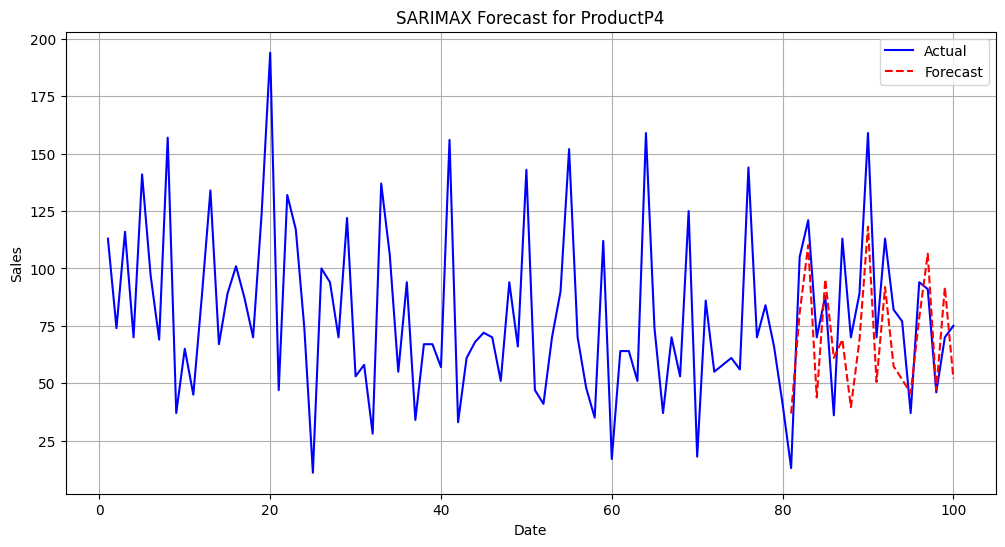

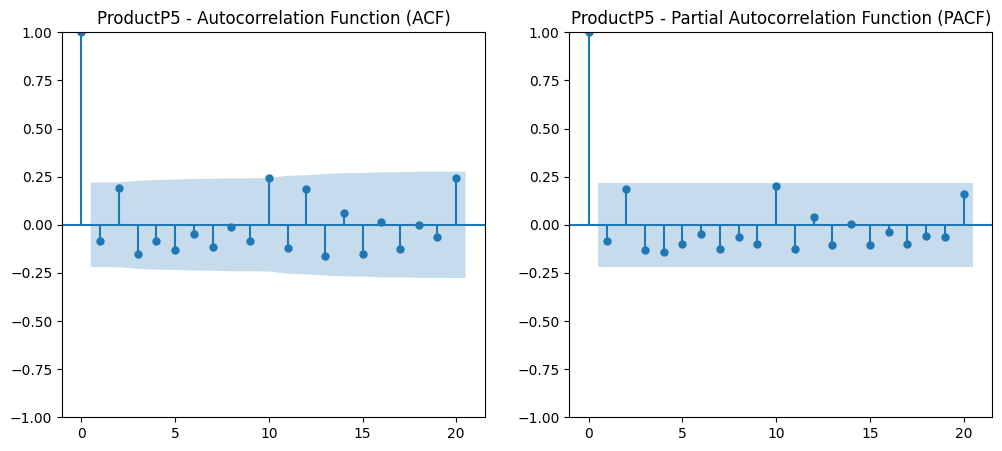

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index

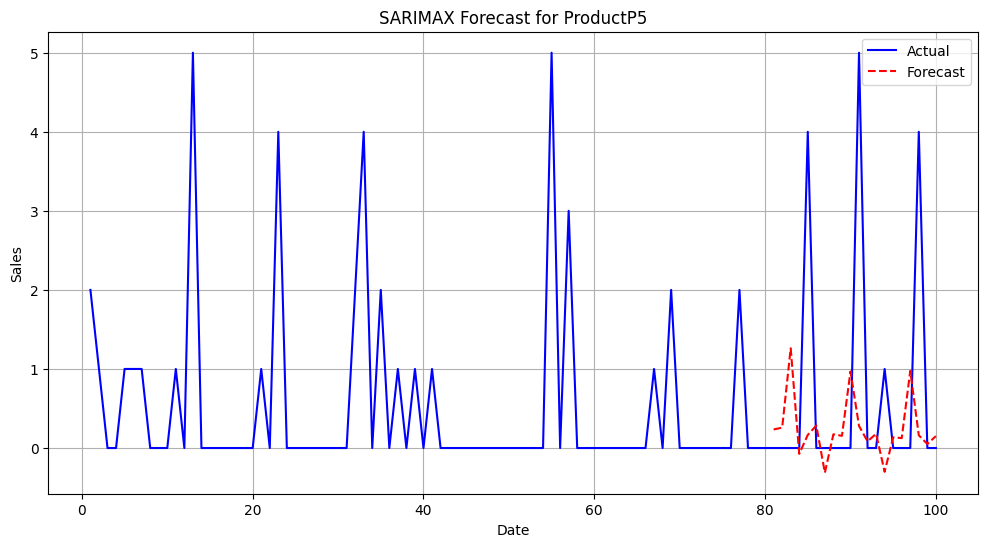

In [34]:
# Forecasting all products
products = ['ProductP1', 'ProductP2', 'ProductP3', 'ProductP4', 'ProductP5']
for product in products:
    endog = df[product]
    exog = df[['price', 'temperature']] if product == 'ProductP4' else None

    # Train-test split
    train_size = int(len(df) * 0.8)
    train, test = endog[:train_size], endog[train_size:]
    exog_train, exog_test = (exog[:train_size], exog[train_size:]) if exog is not None else (None, None)

    # ACF & PACF plots for stationarity analysis
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    plot_acf(train.dropna(), ax=axes[0])
    axes[0].set_title(f"{product} - Autocorrelation Function (ACF)")
    plot_pacf(train.dropna(), ax=axes[1])
    axes[1].set_title(f"{product} - Partial Autocorrelation Function (PACF)")
    plt.show()

    # Fit SARIMAX Model
    model = SARIMAX(train.dropna(), exog=exog_train, order=(1,1,1), seasonal_order=(1,1,1,7))
    results = model.fit()

    # Forecast
    forecast = results.predict(start=len(train), end=len(df)-1, exog=exog_test)

    # Plot Forecast
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df[product], label='Actual', color='blue')
    plt.plot(test.index, forecast, label='Forecast', linestyle='dashed', color='red')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.title(f'SARIMAX Forecast for {product}')
    plt.legend()
    plt.grid(True)
    plt.show()
